In [4]:
# ==========================================
# CELL 1: Install Dependencies & Import
# ==========================================
!pip install torch torchvision scikit-learn matplotlib seaborn pandas torchinfo

import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import drive

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [5]:
# ==========================================
# CELL 2: Data Preprocessing & Augmentation
# ==========================================
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/dataset_kopi'
IMG_SIZE = 224 # Resolusi standar yang adil untuk semua model

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
final_results = [] # Tabel penampung hasil akhir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['imperfection', 'perfect']


In [6]:
# ==========================================
# CELL 3: Core Functions
# ==========================================
class EarlyStopping:
    def __init__(self, patience=4, delta=0):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def train_model(model, criterion, optimizer, num_epochs=15):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    early_stopping = EarlyStopping(patience=4)

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}', end=' ')
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'| {phase.capitalize()} L: {epoch_loss:.4f} A: {epoch_acc:.4f}', end=' ')
            if phase == 'val':
                early_stopping(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc, best_model_wts = epoch_acc, copy.deepcopy(model.state_dict())
        print()
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    model.load_state_dict(best_model_wts)
    return model, history

def evaluate_and_plot_rm(model, history, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    final_results.append({
        "Model": model_name,
        "Train Acc": f"{history['train_acc'][-1]*100:.2f}%",
        "Val Acc": f"{history['val_acc'][-1]*100:.2f}%"
    })

    epochs = range(1, len(history['train_acc']) + 1)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

    ax1.plot(epochs, history['train_acc'], marker='o', label='Train Acc')
    ax1.plot(epochs, history['val_acc'], marker='o', label='Val Acc')
    ax1.set_title(f'Accuracy vs Epochs - {model_name}')
    ax1.legend()

    ax2.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
    ax2.plot(epochs, history['val_loss'], marker='o', label='Val Loss')
    ax2.set_title(f'Loss vs Epochs - {model_name}')
    ax2.legend()
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(all_labels, all_preds)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    plt.figure(figsize=(6, 4))
    bars = plt.bar(class_names, class_acc, color='royalblue')
    plt.title(f'Test Accuracy per Class - {model_name}')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', fontweight='bold')
    plt.show()


--- MODEL 1: VGG-16 ---
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 82.3MB/s]


Epoch 1/15 | Train L: 0.1053 A: 0.9604 | Val L: 0.0001 A: 1.0000 
Epoch 2/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 3/15 | Train L: 0.0001 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 4/15 | Train L: 0.0762 A: 0.9861 | Val L: 0.0286 A: 0.9973 
Epoch 5/15 | Train L: 0.0133 A: 0.9960 | Val L: 0.0000 A: 1.0000 
Epoch 6/15 | Train L: 0.0002 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 7/15 | Train L: 0.0136 A: 0.9974 | Val L: 0.0004 A: 1.0000 
Epoch 8/15 | Train L: 0.0023 A: 0.9987 | Val L: 0.0000 A: 1.0000 
Epoch 9/15 | Train L: 0.0000 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 10/15 | Train L: 0.0000 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Early stopping triggered!


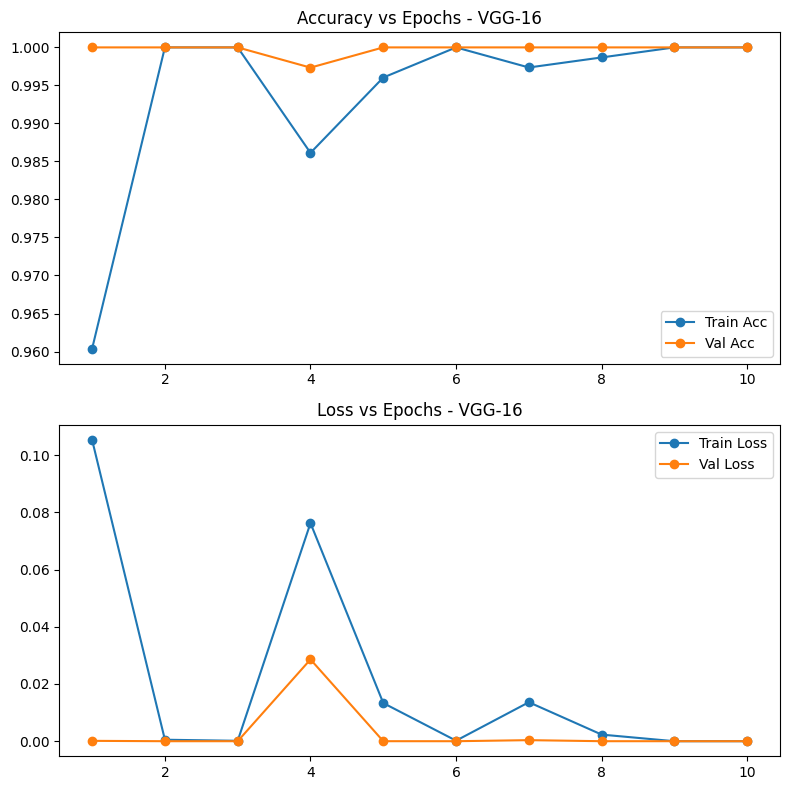

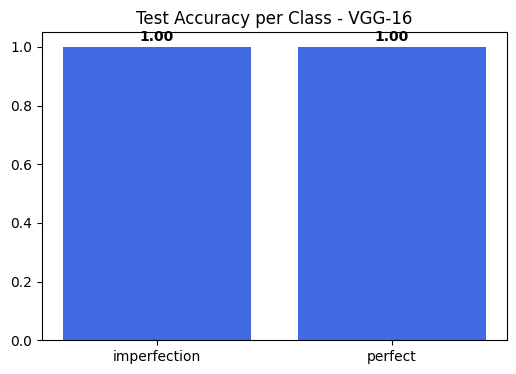

In [7]:
# ==========================================
# CELL 4: VGG-16
# ==========================================
print("\n--- MODEL 1: VGG-16 ---")
model_vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model_vgg.classifier[6] = nn.Linear(4096, 2)
model_vgg = model_vgg.to(device)

model_vgg, hist_vgg = train_model(model_vgg, nn.CrossEntropyLoss(), optim.Adam(model_vgg.parameters(), lr=0.0001), 15)
evaluate_and_plot_rm(model_vgg, hist_vgg, "VGG-16")


--- MODEL 2: ResNet-50 ---
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s]


Epoch 1/15 | Train L: 0.0687 A: 0.9736 | Val L: 0.0002 A: 1.0000 
Epoch 2/15 | Train L: 0.0042 A: 0.9993 | Val L: 0.0001 A: 1.0000 
Epoch 3/15 | Train L: 0.0017 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 4/15 | Train L: 0.0009 A: 1.0000 | Val L: 0.0002 A: 1.0000 
Epoch 5/15 | Train L: 0.0002 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 6/15 | Train L: 0.0004 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 7/15 | Train L: 0.0029 A: 0.9980 | Val L: 0.0158 A: 0.9947 
Epoch 8/15 | Train L: 0.0007 A: 1.0000 | Val L: 0.0010 A: 1.0000 
Epoch 9/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0009 A: 1.0000 
Early stopping triggered!


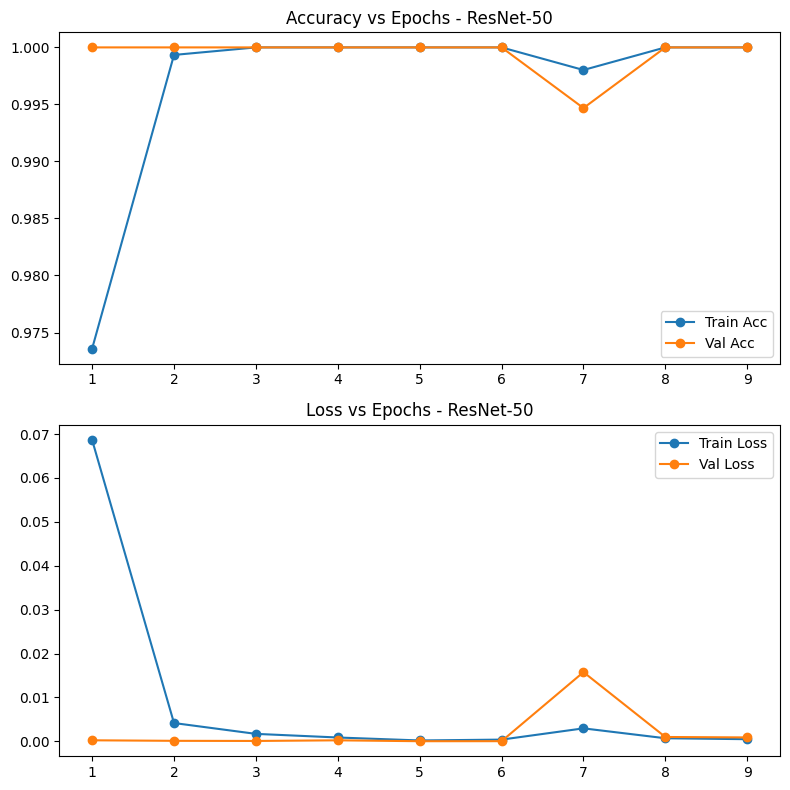

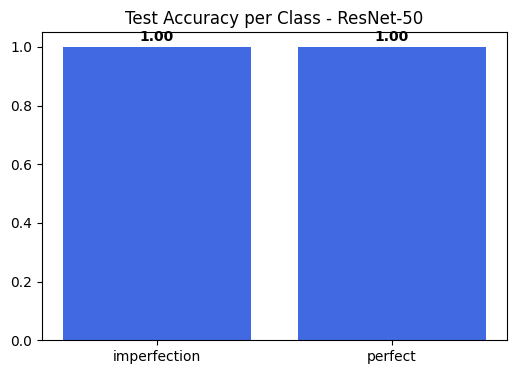

In [8]:
# ==========================================
# CELL 5: ResNet-50
# ==========================================
print("\n--- MODEL 2: ResNet-50 ---")
model_rn = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model_rn.fc = nn.Linear(model_rn.fc.in_features, 2)
model_rn = model_rn.to(device)

model_rn, hist_rn = train_model(model_rn, nn.CrossEntropyLoss(), optim.Adam(model_rn.parameters(), lr=0.0001), 15)
evaluate_and_plot_rm(model_rn, hist_rn, "ResNet-50")


--- MODEL 3: MobileNet-V3 ---
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 178MB/s]

Epoch 1/15 

| Train L: 0.0938 A: 0.9789 | Val L: 0.0850 A: 0.9920 
Epoch 2/15 | Train L: 0.0036 A: 0.9993 | Val L: 0.0060 A: 1.0000 
Epoch 3/15 | Train L: 0.0021 A: 0.9993 | Val L: 0.0018 A: 1.0000 
Epoch 4/15 | Train L: 0.0009 A: 1.0000 | Val L: 0.0005 A: 1.0000 
Epoch 5/15 | Train L: 0.0008 A: 1.0000 | Val L: 0.0005 A: 1.0000 
Epoch 6/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0003 A: 1.0000 
Epoch 7/15 | Train L: 0.0006 A: 1.0000 | Val L: 0.0002 A: 1.0000 
Epoch 8/15 | Train L: 0.0007 A: 1.0000 | Val L: 0.0003 A: 1.0000 
Epoch 9/15 | Train L: 0.0152 A: 0.9980 | Val L: 0.0002 A: 1.0000 
Epoch 10/15 | Train L: 0.0018 A: 0.9993 | Val L: 0.0001 A: 1.0000 
Epoch 11/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 12/15 | Train L: 0.0002 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 13/15 | Train L: 0.0002 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 14/15 | Train L: 0.0001 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 15/15 | Train L: 0.0001 A: 1.0000 | Val L: 0.0000 A: 1.0000 


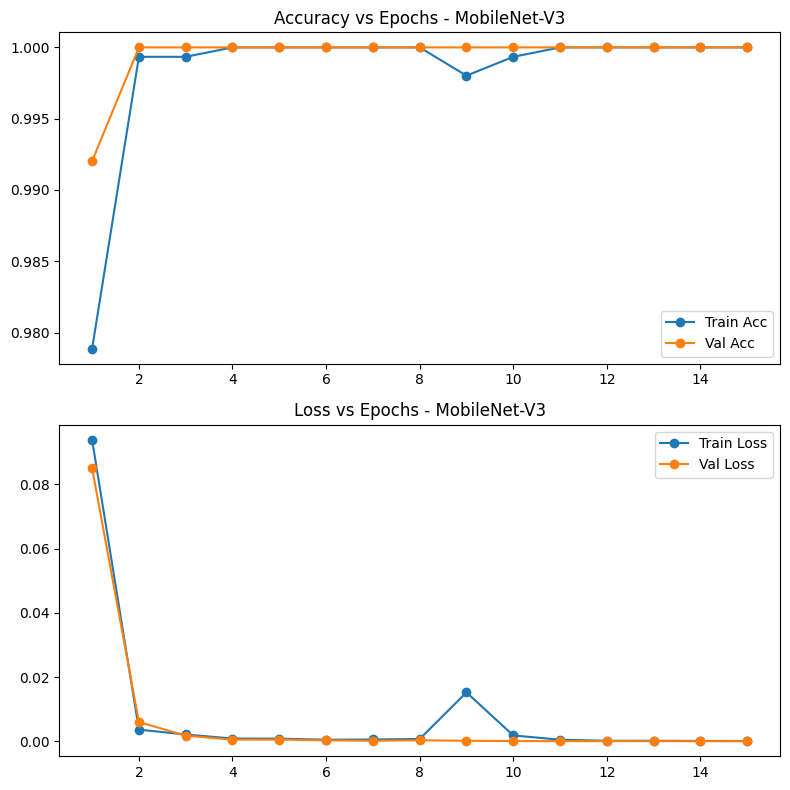

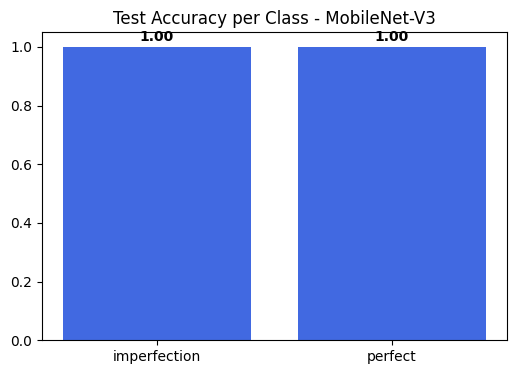

In [9]:
# ==========================================
# CELL 6: MobileNet-V3 Large
# ==========================================
print("\n--- MODEL 3: MobileNet-V3 ---")
model_mn = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
model_mn.classifier[3] = nn.Linear(model_mn.classifier[3].in_features, 2)
model_mn = model_mn.to(device)

model_mn, hist_mn = train_model(model_mn, nn.CrossEntropyLoss(), optim.Adam(model_mn.parameters(), lr=0.0001), 15)
evaluate_and_plot_rm(model_mn, hist_mn, "MobileNet-V3")


--- MODEL 4: DenseNet-121 ---
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 132MB/s]


Epoch 1/15 | Train L: 0.0804 A: 0.9716 | Val L: 0.0027 A: 1.0000 
Epoch 2/15 | Train L: 0.0038 A: 1.0000 | Val L: 0.0009 A: 1.0000 
Epoch 3/15 | Train L: 0.0049 A: 0.9980 | Val L: 0.0004 A: 1.0000 
Epoch 4/15 | Train L: 0.0128 A: 0.9967 | Val L: 0.0011 A: 1.0000 
Epoch 5/15 | Train L: 0.0022 A: 1.0000 | Val L: 0.0002 A: 1.0000 
Epoch 6/15 | Train L: 0.0009 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 7/15 | Train L: 0.0006 A: 1.0000 | Val L: 0.0002 A: 1.0000 
Epoch 8/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 9/15 | Train L: 0.0004 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 10/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 11/15 | Train L: 0.0004 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 12/15 | Train L: 0.0003 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 13/15 | Train L: 0.0002 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 14/15 | Train L: 0.0003 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 15/15 | Train L: 0.0003 A: 1.0000 | Val L: 0.0001 A: 1.0000 


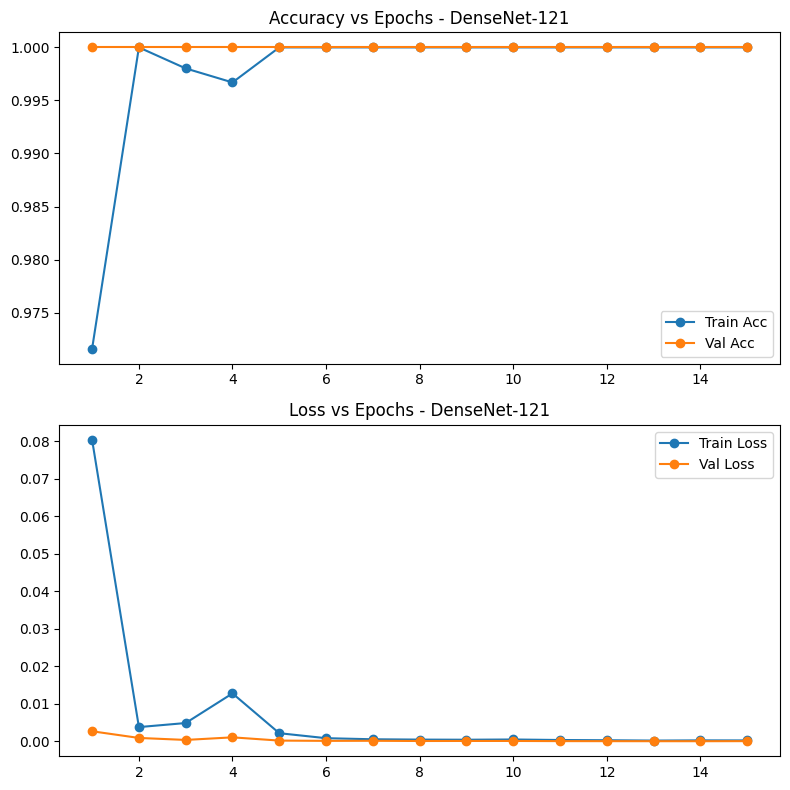

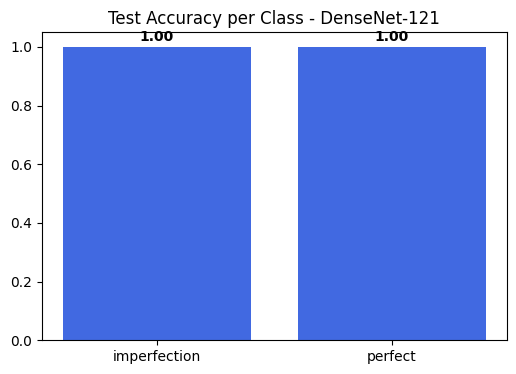

In [10]:
# ==========================================
# CELL 7: DenseNet-121
# ==========================================
print("\n--- MODEL 4: DenseNet-121 ---")
model_dn = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
model_dn.classifier = nn.Linear(model_dn.classifier.in_features, 2)
model_dn = model_dn.to(device)

model_dn, hist_dn = train_model(model_dn, nn.CrossEntropyLoss(), optim.Adam(model_dn.parameters(), lr=0.0001), 15)
evaluate_and_plot_rm(model_dn, hist_dn, "DenseNet-121")


--- MODEL 5: Inception-V3 ---
Menyesuaikan resolusi ke 299x299 khusus untuk Inception-V3...
Epoch 1/15 | Train L: 0.0946 A: 0.9723 | Val L: 0.0009 A: 1.0000 
Epoch 2/15 | Train L: 0.0094 A: 0.9974 | Val L: 0.0016 A: 1.0000 
Epoch 3/15 | Train L: 0.0026 A: 1.0000 | Val L: 0.0004 A: 1.0000 
Epoch 4/15 | Train L: 0.0013 A: 1.0000 | Val L: 0.0003 A: 1.0000 
Epoch 5/15 | Train L: 0.0060 A: 0.9993 | Val L: 0.0008 A: 1.0000 
Epoch 6/15 | Train L: 0.0053 A: 0.9987 | Val L: 0.0009 A: 1.0000 
Epoch 7/15 | Train L: 0.0012 A: 1.0000 | Val L: 0.0003 A: 1.0000 
Epoch 8/15 | Train L: 0.0016 A: 0.9993 | Val L: 0.0003 A: 1.0000 
Early stopping triggered!


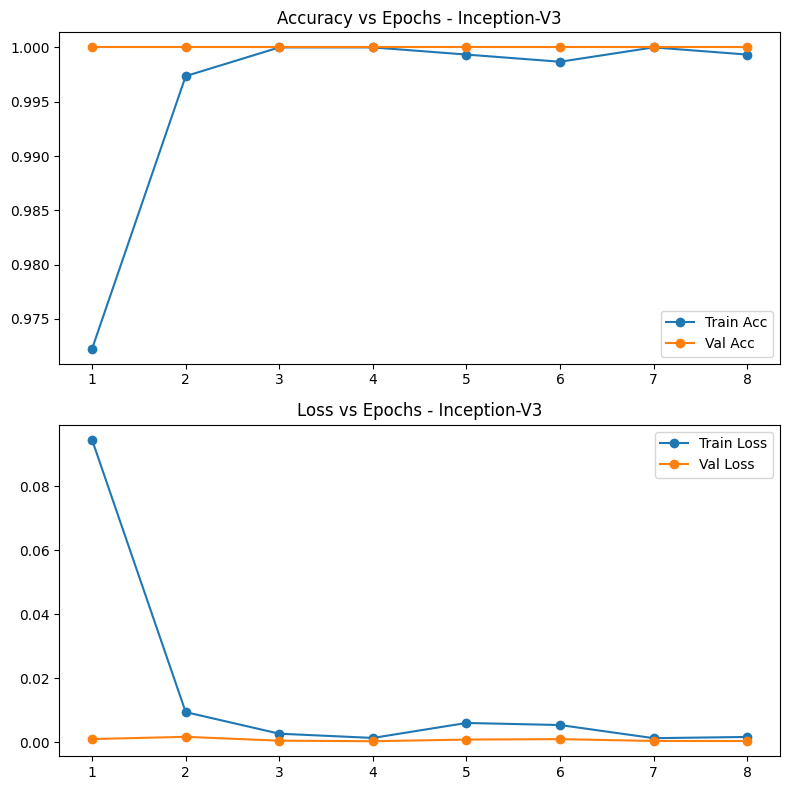

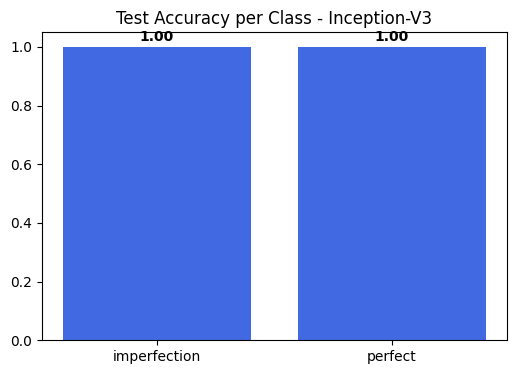

Dataloader berhasil dikembalikan ke standar (224x224).


In [13]:
# ==========================================
# CELL 8: Inception-V3
# ==========================================
print("\n--- MODEL 5: Inception-V3 ---")
print("Menyesuaikan resolusi ke 299x299 khusus untuk Inception-V3...")

# 1. Buat Dataloader sementara khusus ukuran 299
IMG_SIZE_INC = 299
data_transforms_inc = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE_INC, IMG_SIZE_INC)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE_INC, IMG_SIZE_INC)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load data dengan ukuran baru
image_datasets_inc = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms_inc[x]) for x in ['train', 'val']}
dataloaders_inc = {x: DataLoader(image_datasets_inc[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}

# 2. Backup dataloader lama dan timpa dengan yang baru agar terbaca oleh fungsi train_model
dataloaders_backup = dataloaders
dataloaders = dataloaders_inc

# 3. Inisialisasi dan Training Inception-V3
model_inc = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
model_inc.fc = nn.Linear(model_inc.fc.in_features, 2)
model_inc.aux_logits = False # Tetap dimatikan
model_inc = model_inc.to(device)

model_inc, hist_inc = train_model(model_inc, nn.CrossEntropyLoss(), optim.Adam(model_inc.parameters(), lr=0.0001), 15)
evaluate_and_plot_rm(model_inc, hist_inc, "Inception-V3")

# 4. Kembalikan dataloader ke 224x224 untuk model terakhir (EfficientNet-V2-S)
dataloaders = dataloaders_backup
print("Dataloader berhasil dikembalikan ke standar (224x224).")


--- MODEL 6: EfficientNet-V2-S ---
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 156MB/s]


Epoch 1/15 | Train L: 0.1277 A: 0.9630 | Val L: 0.0014 A: 1.0000 
Epoch 2/15 | Train L: 0.0155 A: 0.9954 | Val L: 0.0006 A: 1.0000 
Epoch 3/15 | Train L: 0.0081 A: 0.9987 | Val L: 0.0025 A: 1.0000 
Epoch 4/15 | Train L: 0.0042 A: 0.9993 | Val L: 0.0003 A: 1.0000 
Epoch 5/15 | Train L: 0.0024 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 6/15 | Train L: 0.0014 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 7/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 8/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0001 A: 1.0000 
Epoch 9/15 | Train L: 0.0120 A: 0.9960 | Val L: 0.0013 A: 1.0000 
Epoch 10/15 | Train L: 0.0026 A: 0.9993 | Val L: 0.0000 A: 1.0000 
Epoch 11/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 12/15 | Train L: 0.0014 A: 0.9993 | Val L: 0.0001 A: 1.0000 
Epoch 13/15 | Train L: 0.0050 A: 0.9980 | Val L: 0.0001 A: 1.0000 
Epoch 14/15 | Train L: 0.0005 A: 1.0000 | Val L: 0.0000 A: 1.0000 
Epoch 15/15 | Train L: 0.0002 A: 1.0000 | Val L: 0.0000 A: 1.0000 


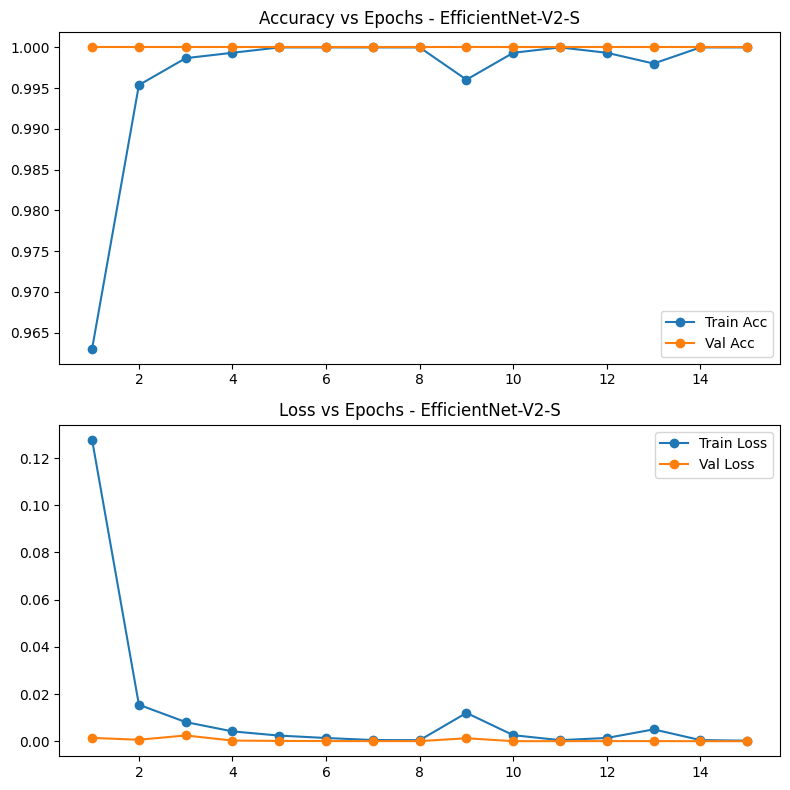

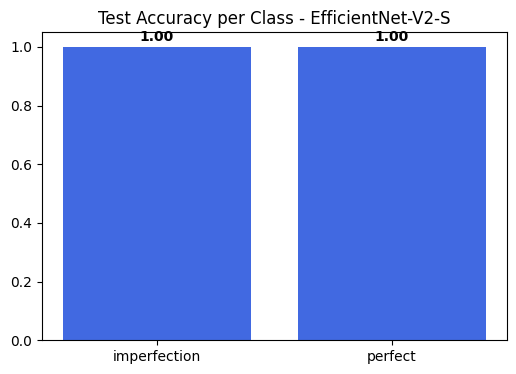

In [14]:
# ==========================================
# CELL 9: EfficientNet-V2-S
# ==========================================
print("\n--- MODEL 6: EfficientNet-V2-S ---")
model_v2s = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
model_v2s.classifier[1] = nn.Linear(model_v2s.classifier[1].in_features, 2)
model_v2s = model_v2s.to(device)

model_v2s, hist_v2s = train_model(model_v2s, nn.CrossEntropyLoss(), optim.Adam(model_v2s.parameters(), lr=0.0001), 15)
evaluate_and_plot_rm(model_v2s, hist_v2s, "EfficientNet-V2-S")

In [15]:
# ==========================================
# CELL 10: Generate Final Summary Table
# ==========================================
from IPython.display import display, HTML

df_results = pd.DataFrame(final_results)
display(HTML("<h3>Final Model Comparison</h3>"))
display(df_results)

,Model,Train Acc,Val Acc
0,VGG-16,100.00%,100.00%
1,ResNet-50,100.00%,100.00%
2,MobileNet-V3,100.00%,100.00%
3,DenseNet-121,100.00%,100.00%
4,Inception-V3,99.93%,100.00%
5,EfficientNet-V2-S,100.00%,100.00%
